# Spatial Analysis of Forest Degradation and Land Surface Temperature Trends in Sindh, Pakistan (2000–2025)

**Course:** Geospatial Analysis  
**Submitted by:** Abdul Rafay (BSCS23031)  
**Date:** May 2025  

---

## Overview

This notebook quantifies and spatially analyses forest degradation across Sindh Province using multi-temporal MODIS and Landsat datasets. The analysis is structured around five core objectives:

1. **Study area delineation** — administrative boundaries
2. **Vegetation change quantification** — NDVI Sen's slope trend + land cover transitions  
3. **Land Surface Temperature (LST) analysis** — ΔLST mapping and classification  
4. **NDVI–LST relationship** — pixel-wise Pearson correlation  
5. **Human infrastructure proximity** — degradation rate and share by distance from roads  

**Data periods** (set by the GEE scripts in `GEE/`):

| Layer | Source | Period |
|---|---|---|
| NDVI Sen's slope | MODIS MOD13Q1 | 2000–2025 (annual medians) |
| Land-cover transition | MODIS MCD12Q1 | 2001 → 2024 |
| ΔLST | Landsat 5/7 vs 8/9 | mean 2018–2024 − mean 2001–2005 |
| NDVI–LST correlation | MODIS MOD13A2 / MOD11A2 | 2000–2025 (monthly) |

---


## 0 · Setup

All imports and path configuration are centralised here. Run this cell first before any other.  
Set `DATA_PATH` and `OUTPUT_PATH` to your local folder locations — no other cell needs modification.


In [1]:
# ── Standard library ──────────────────────────────────────
import numpy as np
import pandas as pd

# ── Geospatial ─────────────────────────────────────────────
import geopandas as gpd
import rasterio
import rioxarray as rxr
import xarray as xr
from rasterio.mask import mask
from rasterio.features import rasterize
from rasterstats import zonal_stats
from shapely.geometry import mapping
from scipy.ndimage import distance_transform_edt
import mapclassify

# ── Visualisation ──────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, to_rgba, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

# ── Statistics ─────────────────────────────────────────────
from scipy.stats import linregress

# ── Global plot style ──────────────────────────────────────
plt.rcParams.update({
    "font.family":    "DejaVu Sans",
    "axes.linewidth": 0.5,
    "figure.dpi":     120,
})

# ── Paths (modify only these two lines) ───────────────────
DATA_PATH   = "data/"
OUTPUT_PATH = "outputs/"

print("✓ Setup complete")
print(f"  DATA_PATH   → {DATA_PATH}")
print(f"  OUTPUT_PATH → {OUTPUT_PATH}")


✓ Setup complete
  DATA_PATH   → data/
  OUTPUT_PATH → outputs/


---
## 1 · Study Area

Load Sindh district boundaries and river network. All subsequent layers are reprojected to match the district CRS.


### 1.1 District Boundaries

In [2]:
districts = gpd.read_file(DATA_PATH + "sindh_districts.gpkg")

print(f"CRS        : {districts.crs}")
print(f"Districts  : {len(districts)}")
print(f"Columns    : {list(districts.columns)}")
districts.head()


CRS        : EPSG:4326
Districts  : 29
Columns    : ['province', 'district', 'district_id', 'geometry']


,province,district,district_id,geometry
0,Sindh,Badin,PK701,"MULTIPOLYGON (((68.96853 25.26637, 68.96903 25..."
1,Sindh,Central Karachi,PK702,"MULTIPOLYGON (((67.09098 25.00239, 67.09104 25..."
2,Sindh,Dadu,PK703,"MULTIPOLYGON (((67.26278 27.3942, 67.26431 27...."
3,Sindh,East Karachi,PK704,"MULTIPOLYGON (((67.15569 25.01068, 67.15708 25..."
4,Sindh,Ghotki,PK705,"MULTIPOLYGON (((69.7619 28.38471, 69.76284 28...."


### 1.2 River Network

In [3]:
rivers = gpd.read_file(
    "zip://" + DATA_PATH + "ne_10m_rivers_lake_centerlines.zip"
)

# Reproject and clip to Sindh extent
rivers      = rivers.to_crs(districts.crs)
sindh_geom  = districts.union_all()
rivers      = gpd.clip(rivers, sindh_geom)

print(f"River segments after clip: {len(rivers)}")


River segments after clip: 1


---
## 2 · Vegetation Change (NDVI 2000–2025 · Land Cover 2001 → 2024)

Two complementary datasets quantify vegetation change:
- **NDVI Sen's slope** (`ndvi_sens_slope.tif`) — pixel-wise rate of change (NDVI units/year)  
- **Land cover transition raster** (`lc_transition.tif`) — encoded from/to class pairs


### 2.1 Load NDVI Trend Raster

In [4]:
ndvi_path = DATA_PATH + "ndvi_sens_slope.tif"

with rasterio.open(ndvi_path) as src:
    ndvi    = src.read(1).astype(float)
    bounds  = src.bounds
    crs     = src.crs
    nodata  = src.nodata

extent_ndvi = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Mask nodata
if nodata is not None:
    ndvi = np.where(ndvi == nodata, np.nan, ndvi)
ndvi = np.where(np.isfinite(ndvi), ndvi, np.nan)

print(f"NDVI raster shape : {ndvi.shape}")
print(f"Value range       : {np.nanmin(ndvi):.4f} – {np.nanmax(ndvi):.4f} NDVI/year")

# Direction of change (±0.002 NDVI/yr = thresholds used for trend classes in GEE_script1.js)
v = ndvi[np.isfinite(ndvi)]
print(f"Valid pixels      : {v.size:,}")
print(f"Positive slope    : {(v > 0).mean():.1%}   (> +0.002/yr, greening class: {(v > 0.002).mean():.1%})")
print(f"Negative slope    : {(v < 0).mean():.1%}   (< −0.002/yr, browning class: {(v < -0.002).mean():.1%})")
print(f"Median slope      : {np.median(v):+.4f} NDVI/year")


NDVI raster shape : (2134, 2018)
Value range       : -0.2062 – 0.2275 NDVI/year
Valid pixels      : 2,498,858
Positive slope    : 88.6%   (> +0.002/yr, greening class: 44.5%)
Negative slope    : 11.4%   (< −0.002/yr, browning class: 4.0%)
Median slope      : +0.0018 NDVI/year


### 2.2 NDVI Trend Map (Greening vs Browning)

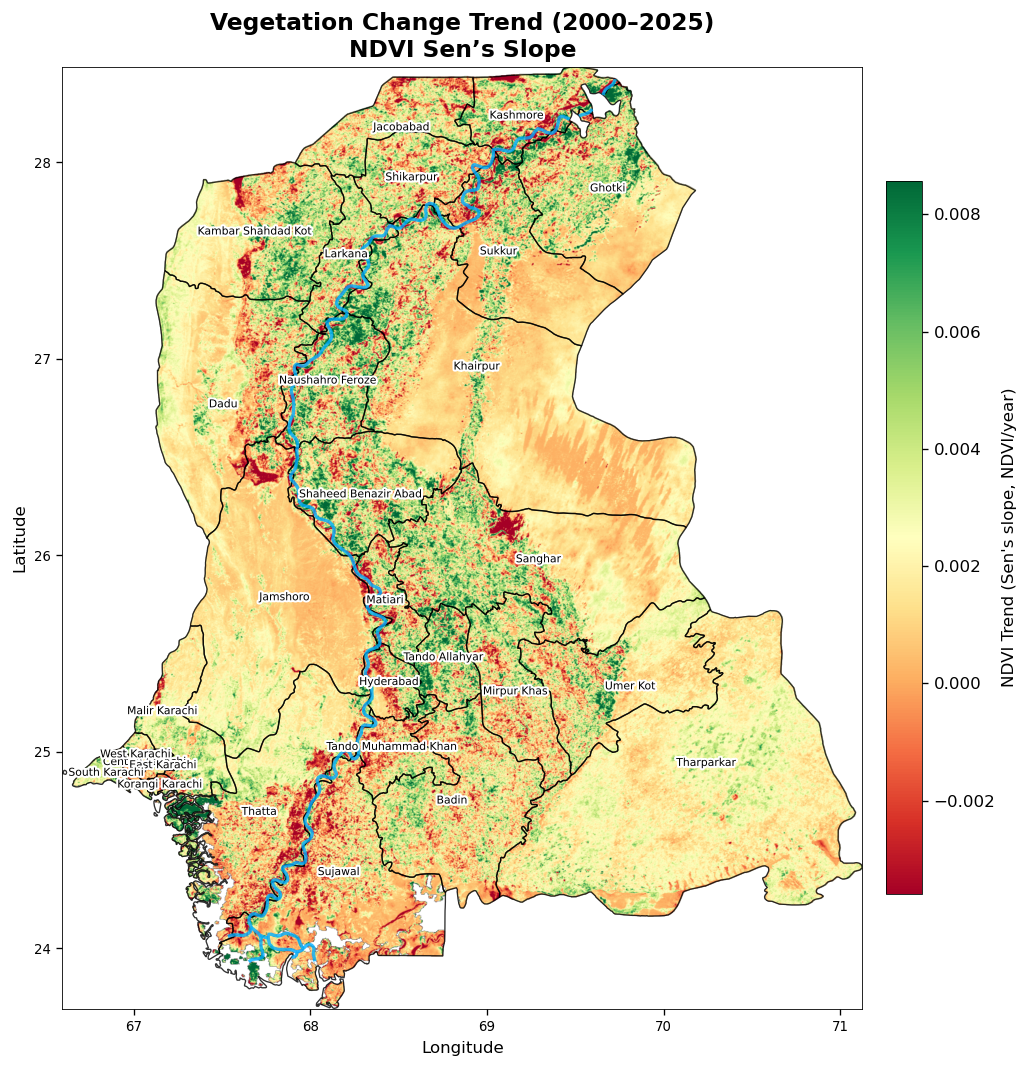

In [5]:
fig, ax = plt.subplots(figsize=(11, 9))

# =========================================================
# NDVI RASTER
# =========================================================
vmin, vmax = np.nanpercentile(ndvi, [2, 98])

img = ax.imshow(
    ndvi,
    cmap="RdYlGn",
    vmin=vmin,
    vmax=vmax,
    extent=extent_ndvi,
    interpolation="bilinear",
    zorder=1
)

rivers.plot(
    ax=ax,
    color="#00AEFF",
    linewidth=2,
    alpha=0.8,
    zorder=4
)

# =========================================================
# DISTRICT BOUNDARIES
# =========================================================
districts.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    zorder=3
)

# =========================================================
# DISTRICT LABELS 
# =========================================================
for _, row in districts.iterrows():
    if row.geometry is None:
        continue

    # representative point avoids label falling outside polygon
    pt = row.geometry.representative_point()

    ax.text(
        pt.x,
        pt.y,
        str(row["district"]),
        fontsize=6.5,
        color="black",
        ha="center",
        va="center",
        path_effects=[pe.withStroke(linewidth=2.5, foreground="white")],
        zorder=4
    )

# =========================================================
# FORMATTING
# =========================================================
ax.set_title(
    "Vegetation Change Trend (2000–2025)\nNDVI Sen’s Slope",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.tick_params(labelsize=8)

# =========================================================
# COLORBAR
# =========================================================
cbar = plt.colorbar(img, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("NDVI Trend (Sen's slope, NDVI/year)")

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "ndvi_trend_map.png", dpi=300)
plt.show()

### 2.3 Load Land Cover Transition Raster

In [6]:
lc_path = DATA_PATH + "lc_transition.tif"

with rasterio.open(lc_path) as src:
    lc         = src.read(1).astype(float)
    lc_bounds  = src.bounds
    nd         = src.nodata
    lc_crs     = src.crs
    lc_shape   = (src.height, src.width)
    lc_transform = src.transform

    # Reproject districts to match raster CRS
    districts  = districts.to_crs(lc_crs)

extent_lc = [lc_bounds.left, lc_bounds.right, lc_bounds.bottom, lc_bounds.top]

# Clean nodata
if nd is not None:
    lc = np.where(lc == nd, np.nan, lc)
lc = np.where(np.isfinite(lc), lc, np.nan)

# Transition codes are from_class * 10 + to_class (classes 1–7, see GEE_script2.js),
# so no valid pixel is 0. GEE exports masked (outside-Sindh) pixels as 0 → no-data.
LC_NODATA = 0
VEG       = [1, 2, 3]
LC_LABELS = ["Stable", "Veg→Urban", "Veg→Cropland", "Veg loss", "Veg gain", "Other"]


def decode_transitions(raw):
    """Decode transition codes into classes 0–5; no-data pixels stay NaN."""
    raw = np.where(raw == LC_NODATA, np.nan, raw)
    valid = np.isfinite(raw)
    fc = np.floor(raw / 10)   # from class
    tc = raw % 10             # to class

    cls = np.full(raw.shape, np.nan)
    cls[valid]                                      = 5   # Other transition
    cls[valid & (fc == tc)]                         = 0   # Stable
    cls[np.isin(fc, VEG) & (tc == 5)]               = 1   # Veg → Urban
    cls[np.isin(fc, VEG) & (tc == 4)]               = 2   # Veg → Cropland
    cls[np.isin(fc, VEG) & np.isin(tc, [6, 7])]     = 3   # Vegetation loss
    cls[np.isin(fc, [4, 6]) & np.isin(tc, VEG)]     = 4   # Vegetation gain
    return cls


cls_lc   = decode_transitions(lc)
n_valid  = int(np.isfinite(cls_lc).sum())

print(f"Land cover raster shape : {lc.shape}")
print(f"Valid pixels            : {n_valid:,}  (no-data excluded: {lc.size - n_valid:,})")
for v, label in enumerate(LC_LABELS):
    n = int((cls_lc == v).sum())
    print(f"  Class {v} ({label:>14}) : {n:>8,} px  ({n / n_valid:6.2%} of valid)")


Land cover raster shape : (1067, 1010)
Valid pixels            : 634,151  (no-data excluded: 443,519)
  Class 0 (        Stable) :  431,658 px  (68.07% of valid)
  Class 1 (     Veg→Urban) :       12 px  ( 0.00% of valid)
  Class 2 (  Veg→Cropland) :   50,074 px  ( 7.90% of valid)
  Class 3 (      Veg loss) :   25,046 px  ( 3.95% of valid)
  Class 4 (      Veg gain) :   21,192 px  ( 3.34% of valid)
  Class 5 (         Other) :  106,169 px  (16.74% of valid)


### 2.4 Land Cover Transition Map

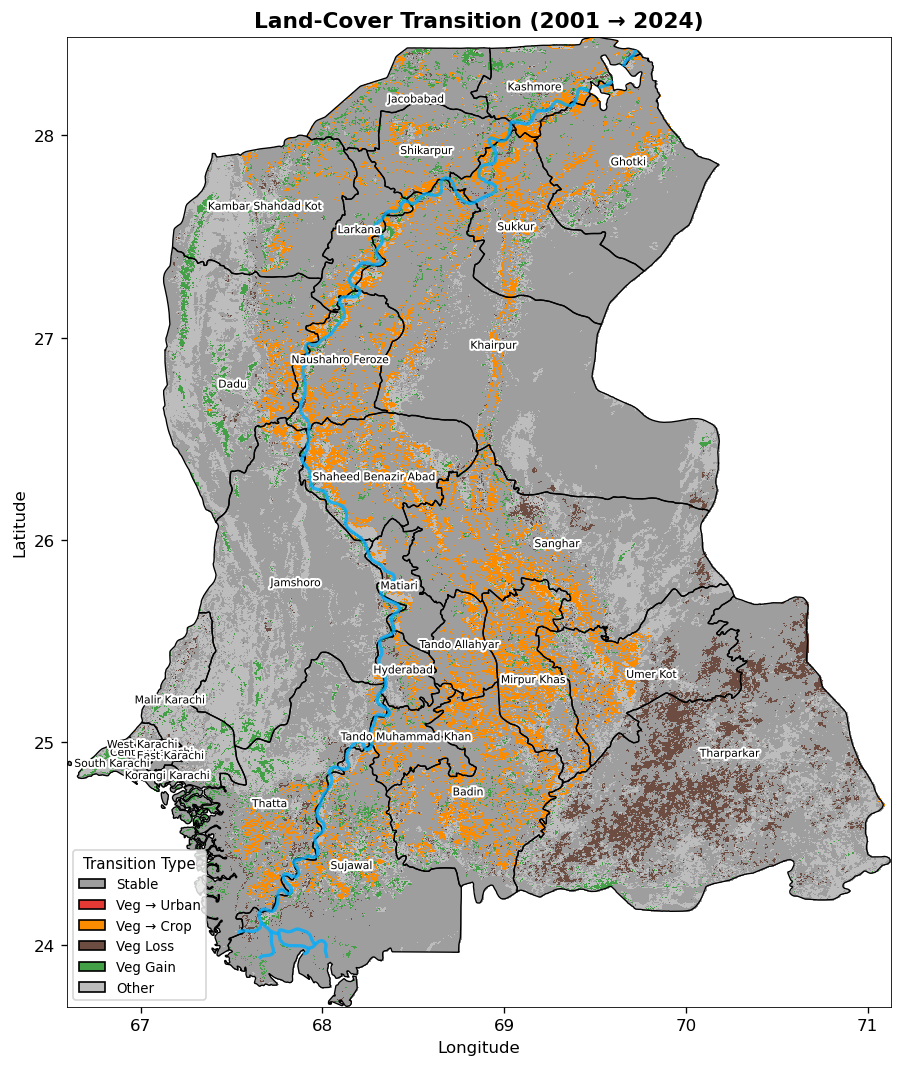

In [7]:
colors = [
    "#9e9e9e",  # stable
    "#e53935",  # veg → urban
    "#fb8c00",  # veg → cropland
    "#6d4c41",  # loss
    "#43a047",  # gain
    "#bdbdbd"   # other
]

cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(11, 9))

# =========================================================
# MAIN RASTER
# =========================================================
im = ax.imshow(
    cls_lc,
    cmap=cmap,
    vmin=0,
    vmax=len(colors) - 1,
    extent=extent_lc,
    origin="upper",
    interpolation="nearest",
    aspect="auto"
)

rivers.plot(
    ax=ax,
    color="#00AEFF",
    linewidth=2,
    alpha=0.8,
    zorder=4
)

# =========================================================
# DISTRICTS
# =========================================================
districts.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.8
)

# =========================================================
# DISTRICT LABELS 
# =========================================================
for _, row in districts.iterrows():
    if row.geometry is None:
        continue

    # representative point avoids label falling outside polygon
    pt = row.geometry.representative_point()

    ax.text(
        pt.x,
        pt.y,
        str(row["district"]),
        fontsize=6.5,
        color="black",
        ha="center",
        va="center",
        path_effects=[pe.withStroke(linewidth=2.5, foreground="white")],
        zorder=4
    )

# =========================================================
# FORMATTING
# =========================================================
ax.set_xlim(extent_lc[0], extent_lc[1])
ax.set_ylim(extent_lc[2], extent_lc[3])
ax.set_title("Land-Cover Transition (2001 → 2024)", fontsize=13, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# =========================================================
# LEGEND
# =========================================================

legend_elements = [
    Patch(facecolor=colors[0], edgecolor="black", label="Stable"),
    Patch(facecolor=colors[1], edgecolor="black", label="Veg → Urban"),
    Patch(facecolor=colors[2], edgecolor="black", label="Veg → Crop"),
    Patch(facecolor=colors[3], edgecolor="black", label="Veg Loss"),
    Patch(facecolor=colors[4], edgecolor="black", label="Veg Gain"),
    Patch(facecolor=colors[5], edgecolor="black", label="Other")
]

ax.legend(
    handles=legend_elements,
    title="Transition Type",
    loc="lower left",
    fontsize=8,
    title_fontsize=9,
)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "landcover_transition_map.png", dpi=300)
plt.show()

---
## 3 · Land Surface Temperature Change

ΔLST raster derived from Landsat thermal band differencing: mean LST 2018–2024 (Landsat 8/9) minus mean LST 2001–2005 (Landsat 5 + pre-SLC-failure Landsat 7).  
Positive values = warming; negative = cooling.


### 3.1 Load ΔLST Raster

In [8]:
tif_path = DATA_PATH + "delta_lst_landsat.tif"

da = rxr.open_rasterio(
    tif_path,
    masked=True,
    chunks=True
)

delta = da.sel(band=1)

print(delta)

<xarray.DataArray (y: 17776, x: 16804)> Size: 2GB
dask.array<getitem, shape=(17776, 16804), dtype=float64, chunksize=(4096, 4096), chunktype=numpy.ndarray>
Coordinates:
    band         int64 8B 1
  * x            (x) float64 134kB 66.6 66.6 66.6 66.6 ... 71.12 71.12 71.12
  * y            (y) float64 142kB 28.48 28.48 28.48 28.48 ... 23.7 23.69 23.69
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      delta_lst


### 3.2 Classify ΔLST (Cooling / Stable / Warming)

In [9]:
# Three-class thermal classification (valid pixels only)
# 0 = cooling  (ΔLST < −0.5°C)
# 1 = stable   (−0.5 ≤ ΔLST ≤ +0.5°C)
# 2 = warming  (ΔLST > +0.5°C)
# NaN compares False with everything, so without the mask no-data would land in "warming".
valid_lst = delta.notnull()
cls_lst = xr.where(delta < -0.5, 0,
          xr.where(delta <= 0.5, 1, 2)).where(valid_lst)

# Summary (single pass over the raster)
lst_stats = xr.Dataset({
    "valid":   valid_lst.sum(),
    "cooling": (cls_lst == 0).sum(),
    "stable":  (cls_lst == 1).sum(),
    "warming": (cls_lst == 2).sum(),
    "mean":    delta.mean(),
}).compute()

n_valid = int(lst_stats["valid"])
print(f"  Valid pixels : {n_valid:,} of {delta.size:,} ({n_valid / delta.size:.1%})")
for v, label in [(0,"Cooling"), (1,"Stable"), (2,"Warming")]:
    n = int(lst_stats[label.lower()])
    print(f"  {label:>8} (class {v}): {n:>12,} px  ({n / n_valid:6.2%} of valid)")
print(f"  Mean ΔLST    : {float(lst_stats['mean']):+.2f} °C")


  Valid pixels : 175,181,275 of 298,707,904 (58.6%)
   Cooling (class 0):   18,771,493 px  (10.72% of valid)
    Stable (class 1):    9,589,743 px  ( 5.47% of valid)
   Warming (class 2):  146,820,039 px  (83.81% of valid)
  Mean ΔLST    : +4.16 °C


### 3.3 ΔLST Map

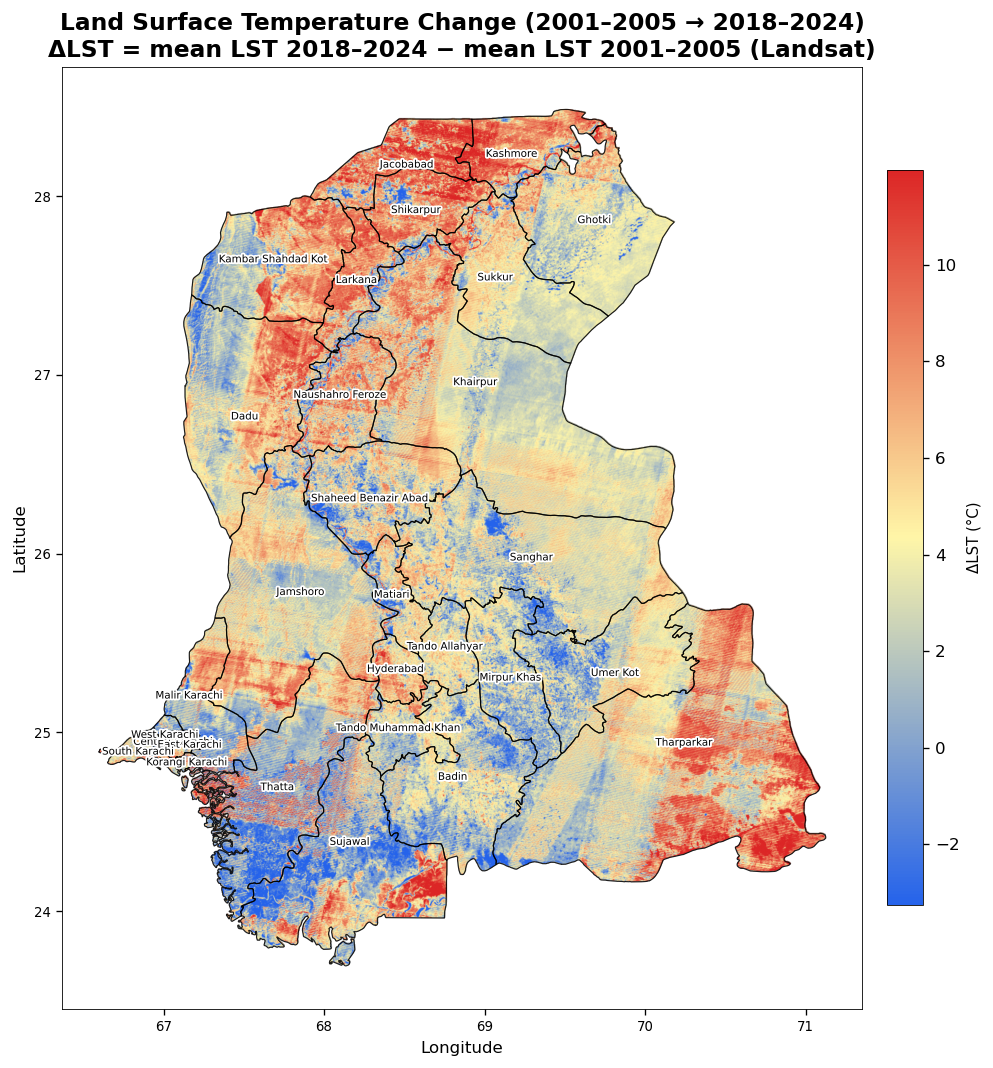

In [10]:
# =========================================================
# DOWNSAMPLE FOR DISPLAY ONLY
# =========================================================
delta_small = delta.coarsen(
    x=10,
    y=10,
    boundary="trim"
).mean().compute()

# =========================================================
# CUSTOM ΔLST COLOR RAMP
# cooling → stable → warming
# =========================================================
cmap = LinearSegmentedColormap.from_list(
    "lst",
    [
        "#2563eb",  # cooling blue
        "#fff6a8",  # neutral white
        "#dc2626"   # warming red
    ]
)

# =========================================================
# ROBUST STRETCH
# =========================================================
vmin = float(np.nanpercentile(delta_small.values, 2))
vmax = float(np.nanpercentile(delta_small.values, 98))

# =========================================================
# FIGURE
# =========================================================
fig, ax = plt.subplots(figsize=(11, 9))

# =========================================================
# ΔLST RASTER
# =========================================================
img = ax.imshow(
    delta_small,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    extent=[float(delta_small.x.min()), float(delta_small.x.max()),
            float(delta_small.y.min()), float(delta_small.y.max())],
    origin="upper",
    interpolation="bilinear",
    zorder=1
)

# =========================================================
# DISTRICT BOUNDARIES
# =========================================================
districts.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.85,
    zorder=3
)

# =========================================================
# DISTRICT LABELS
# =========================================================
for _, row in districts.iterrows():

    if row.geometry is None:
        continue

    pt = row.geometry.representative_point()

    ax.text(
        pt.x,
        pt.y,
        str(row["district"]),
        fontsize=6.2,
        color="black",
        ha="center",
        va="center",
        path_effects=[
            pe.withStroke(
                linewidth=2.2,
                foreground="white"
            )
        ],
        zorder=4
    )

# =========================================================
# FORMATTING
# =========================================================
ax.set_title(
    "Land Surface Temperature Change (2001–2005 → 2018–2024)\nΔLST = mean LST 2018–2024 − mean LST 2001–2005 (Landsat)",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.tick_params(labelsize=8)

# =========================================================
# COLORBAR
# =========================================================
cbar = plt.colorbar(
    img,
    ax=ax,
    fraction=0.03,
    pad=0.02
)

cbar.set_label(
    "ΔLST (°C)",
    fontsize=9
)

# =========================================================
# CLEAN STYLE
# =========================================================
ax.grid(False)

plt.tight_layout()

plt.savefig(
    OUTPUT_PATH + "delta_lst_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Known artefacts in the ΔLST map

Two kinds of striping are visible. Both come from how the Landsat composites were built in `GEE/GEE_script3.js`, not from the land surface:

1. **Fine near-horizontal hatching (~500 m period).** A 2-D FFT of homogeneous windows (Jamshoro, Tharparkar) shows a dominant period of ~16.7 px ≈ 500 m, with a harmonic at ~1 km, oriented along the scan direction (~9° from E–W). That matches the 16-line / 480 m scan period of the whiskbroom TM (Landsat 5) and ETM+ (Landsat 7) sensors, so it is detector/scan striping in the **early (2001–2005) thermal composite**. It is *not* Landsat 7 SLC-off gaps: the script only uses Landsat 7 scenes before 2003-05-01, a month before the SLC failure (31 May 2003), and the raster has no gap lines of missing data.
2. **Broad diagonal bands with straight edges (~1.5° apart).** These follow Landsat WRS-2 path/scene footprints. `mean()` averages every cloud-free scene regardless of season, so neighbouring paths with different numbers and dates of acquisitions get different seasonal mixes, and the difference shows up as a step at the path edge.

Neither artefact changes the method, but both add non-physical local variation, so pixel-level ΔLST (especially near path edges) should be read with caution; the province-wide class percentages are more robust than any single pixel. A cleaner export would restrict both periods to the same season (e.g. Mar–May), use `median()` instead of `mean()`, and/or use a consistent sensor such as MODIS MOD11A2 LST.


---
## 4 . Pixel-Level NDVI–LST Correlation

Valid pixels       : 155,509
Significant (p<.05): 96.2% of valid
  negative r       : 98.2% of significant
  positive r       : 1.8% of significant
Median r (all)     : -0.36


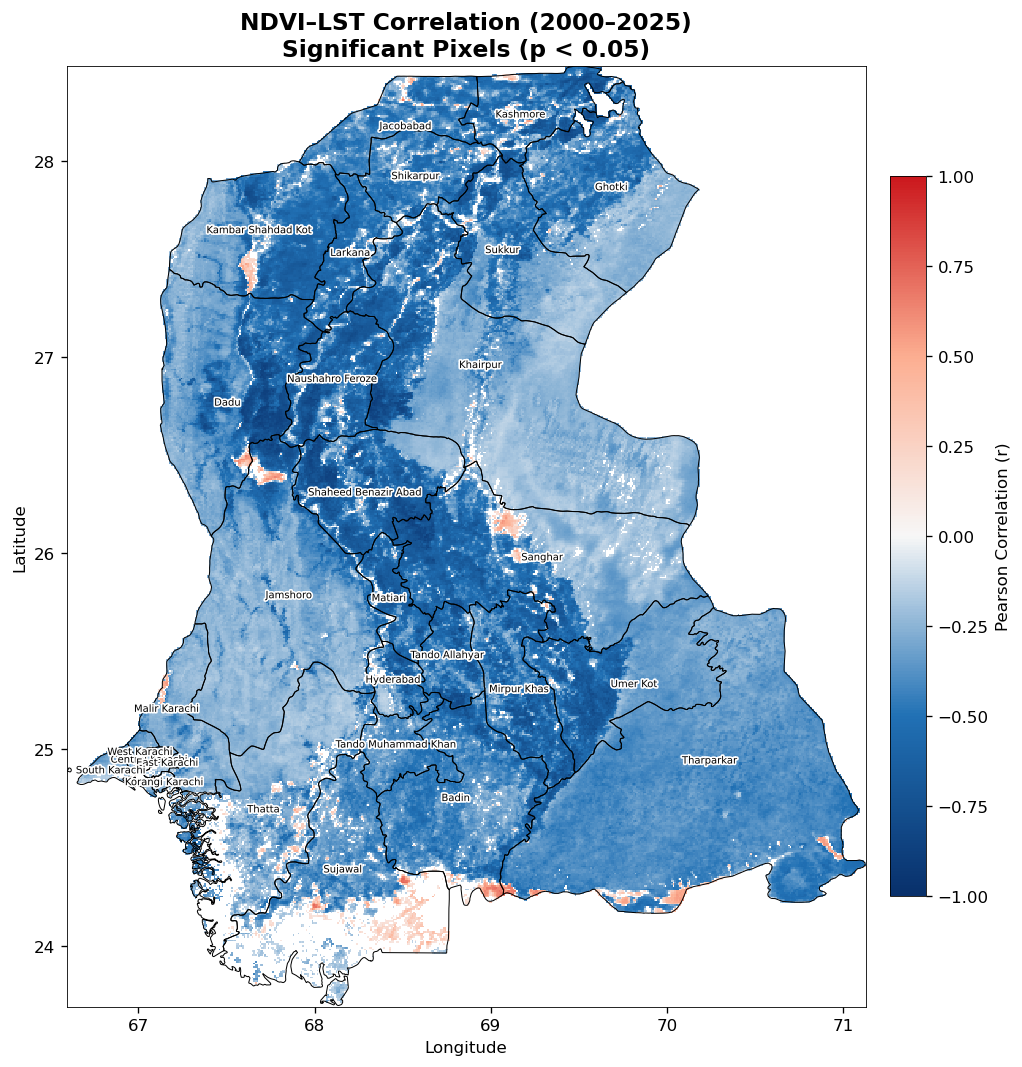

In [11]:
# =========================================================
# LOAD EXPORT FROM GEE
# =========================================================
tif_path = DATA_PATH + "ndvi_lst_corr.tif"

ds = rxr.open_rasterio(tif_path, masked=True)

# Band 1 = pearson r
r = ds.sel(band=1).squeeze()

# Band 2 = p-value
p = ds.sel(band=2).squeeze()

# =========================================================
# MASK NON-SIGNIFICANT PIXELS
# =========================================================
r_sig = r.where(p < 0.05)

n_valid_r = int(r.notnull().sum())
n_sig     = int(r_sig.notnull().sum())
print(f"Valid pixels       : {n_valid_r:,}")
print(f"Significant (p<.05): {n_sig / n_valid_r:.1%} of valid")
print(f"  negative r       : {float((r_sig < 0).sum()) / n_sig:.1%} of significant")
print(f"  positive r       : {float((r_sig > 0).sum()) / n_sig:.1%} of significant")
print(f"Median r (all)     : {float(r.median()):+.2f}")

# =========================================================
# COLORMAP (diverging)
# =========================================================
cmap = LinearSegmentedColormap.from_list(
    "corr",
    ["#08306b", "#2171b5", "#f7f7f7", "#fcae91", "#cb181d"]
)

# =========================================================
# PLOT
# =========================================================
fig, ax = plt.subplots(figsize=(11, 9), facecolor="white")

img = r_sig.plot(
    ax=ax,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    add_colorbar=False,
    zorder=1
)

# =========================================================
# DISTRICT BOUNDARIES
# =========================================================
districts.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.6,
    zorder=3
)

# =========================================================
# LABELS
# =========================================================
for _, row in districts.iterrows():
    pt = row.geometry.representative_point()

    ax.text(
        pt.x,
        pt.y,
        row["district"],
        fontsize=6,
        ha="center",
        va="center",
        color="black",
        path_effects=[pe.withStroke(linewidth=2, foreground="white")],
        zorder=4
    )

# =========================================================
# TITLE
# =========================================================
ax.set_title(
    "NDVI–LST Correlation (2000–2025)\nSignificant Pixels (p < 0.05)",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# =========================================================
# COLORBAR
# =========================================================
cbar = plt.colorbar(img, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Pearson Correlation (r)")

plt.tight_layout()
plt.savefig(
    OUTPUT_PATH + "ndvi_lst_corr.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

---
## 5 · Human Infrastructure Proximity

Euclidean distance from the road network is used as a proxy for human access pressure.  
Degradation rates are compared across distance bands to test whether proximity to roads predicts land cover change.

**Hypothesis:** Degradation rates decrease with distance from roads (distance-decay effect).


### 5.1 Load Raster + Road Data

In [12]:
tif_path      = DATA_PATH + "lc_transition.tif"
roads_path    = DATA_PATH + "sindh_roads.gpkg"

# ── Raster ─────────────────────────────────────────────────
with rasterio.open(tif_path) as src:
    trans        = src.read(1).astype(float)
    nd           = src.nodata
    raster_crs   = src.crs
    transform    = src.transform
    shape        = (src.height, src.width)
    bounds       = src.bounds

extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
PIXEL_M = 500   # MODIS LC resolution = 500 m

# Clean + classify with the Section 2.3 decoder (no-data → NaN)
if nd is not None:
    trans = np.where(trans == nd, np.nan, trans)

cls   = decode_transitions(trans)
valid = np.isfinite(cls)

# ── Roads ──────────────────────────────────────────────────
roads     = gpd.read_file(roads_path)
districts = gpd.read_file(DATA_PATH + "sindh_districts.gpkg")

if roads.crs != raster_crs:
    roads = roads.to_crs(raster_crs)
if districts.crs != raster_crs:
    districts = districts.to_crs(raster_crs)

important = ["motorway","trunk","primary","secondary","tertiary","track"]
roads = roads[roads["highway"].isin(important)].copy()

print(f"Raster shape          : {shape}")
print(f"Pixel size            : {PIXEL_M} m")
print(f"Road features (filtered) : {len(roads):,}")


Raster shape          : (1067, 1010)
Pixel size            : 500 m
Road features (filtered) : 23,450


### 5.2 Rasterise Roads

In [13]:
road_shapes = [(geom, 1) for geom in roads.geometry if geom is not None]
 
road_raster = rasterize(
    shapes      = road_shapes,
    out_shape   = shape,          # (height, width) from src — always correct
    transform   = transform,
    fill        = 0,
    dtype       = np.uint8,
    all_touched = True,
)
 
print(f"road_raster shape : {road_raster.shape}")
print(f"Road pixels       : {road_raster.sum():,}")


road_raster shape : (1067, 1010)
Road pixels       : 74,416


### 5.3 Distance Transform

In [14]:
dist_pixels = distance_transform_edt(road_raster == 0)
dist_m      = dist_pixels * PIXEL_M
 
print(f"dist_m shape   : {dist_m.shape}")
print(f"cls shape      : {cls.shape}")
print(f"valid shape    : {valid.shape}")
print(f"Distance range : {dist_m.min():.0f} m – {dist_m.max()/1000:.1f} km")
 
assert dist_m.shape == cls.shape == valid.shape, \
    f"Shape mismatch: dist={dist_m.shape}, cls={cls.shape}, valid={valid.shape}"
print("✓ All shapes match")


dist_m shape   : (1067, 1010)
cls shape      : (1067, 1010)
valid shape    : (1067, 1010)
Distance range : 0 m – 138.2 km
✓ All shapes match


### 5.4 Degradation Rate and Share by Distance Band

- **Rate** — % of valid land in the band that degraded (does degradation become *more likely* near roads?)
- **Share** — % of all degraded pixels that fall in the band (*where* does degradation happen?). Share also depends on how much land each band covers, so the two answer different questions.

In [15]:
# Degradation = natural vegetation converted to urban, cropland or barren/water
# (classes 1–3 of the Section 2.3 scheme). Vegetation gain (4) and "Other" (5) are excluded.
DEGRADATION_CLASSES = [1, 2, 3]
degradation = np.isin(cls, DEGRADATION_CLASSES)   # NaN (no-data) is never degraded

bins   = [0, 500, 1_000, 5_000, 10_000, np.inf]
labels = ["0–500 m", "500 m–1 km", "1–5 km", "5–10 km", ">10 km"]

n_deg_all = int((degradation & valid).sum())

rows = []
for i in range(len(bins) - 1):
    in_band = (dist_m >= bins[i]) & (dist_m < bins[i + 1]) & valid
    n_total = int(in_band.sum())
    n_deg   = int((in_band & degradation).sum())
    rows.append({
        "band":        labels[i],
        "degraded_px": n_deg,
        "land_px":     n_total,
        "rate_pct":    n_deg / n_total * 100 if n_total > 0 else 0,
        "share_pct":   n_deg / n_deg_all * 100,
    })

band_stats = pd.DataFrame(rows)
rate_pct   = band_stats["rate_pct"].tolist()
share_pct  = band_stats["share_pct"].tolist()

print(f"Valid land pixels : {int(valid.sum()):,}")
print(f"Degraded pixels   : {n_deg_all:,} ({n_deg_all / valid.sum():.2%} of valid land)\n")
print(f"{'Band':<12} {'Degraded px':>12} {'Land px':>10} {'Rate %':>8} {'Share %':>8}")
print("-" * 54)
for r in rows:
    print(f"{r['band']:<12} {r['degraded_px']:>12,} {r['land_px']:>10,} "
          f"{r['rate_pct']:>7.1f}% {r['share_pct']:>7.1f}%")

for limit_m, name in [(1_000, "1 km"), (5_000, "5 km")]:
    near  = (dist_m < limit_m) & valid
    n_d   = int((near & degradation).sum())
    print(f"\nWithin {name}: rate {n_d / near.sum():.1%}, share {n_d / n_deg_all:.1%}, "
          f"land {near.sum() / valid.sum():.1%} of Sindh")


Valid land pixels : 634,151
Degraded pixels   : 75,132 (11.85% of valid land)

Band          Degraded px    Land px   Rate %  Share %
------------------------------------------------------
0–500 m            10,192     74,416    13.7%    13.6%
500 m–1 km         16,894    114,159    14.8%    22.5%
1–5 km             42,415    294,533    14.4%    56.5%
5–10 km             4,724     76,567     6.2%     6.3%
>10 km                907     74,476     1.2%     1.2%

Within 1 km: rate 14.4%, share 36.1%, land 29.7% of Sindh

Within 5 km: rate 14.4%, share 92.5%, land 76.2% of Sindh


### 5.5 Proximity Chart

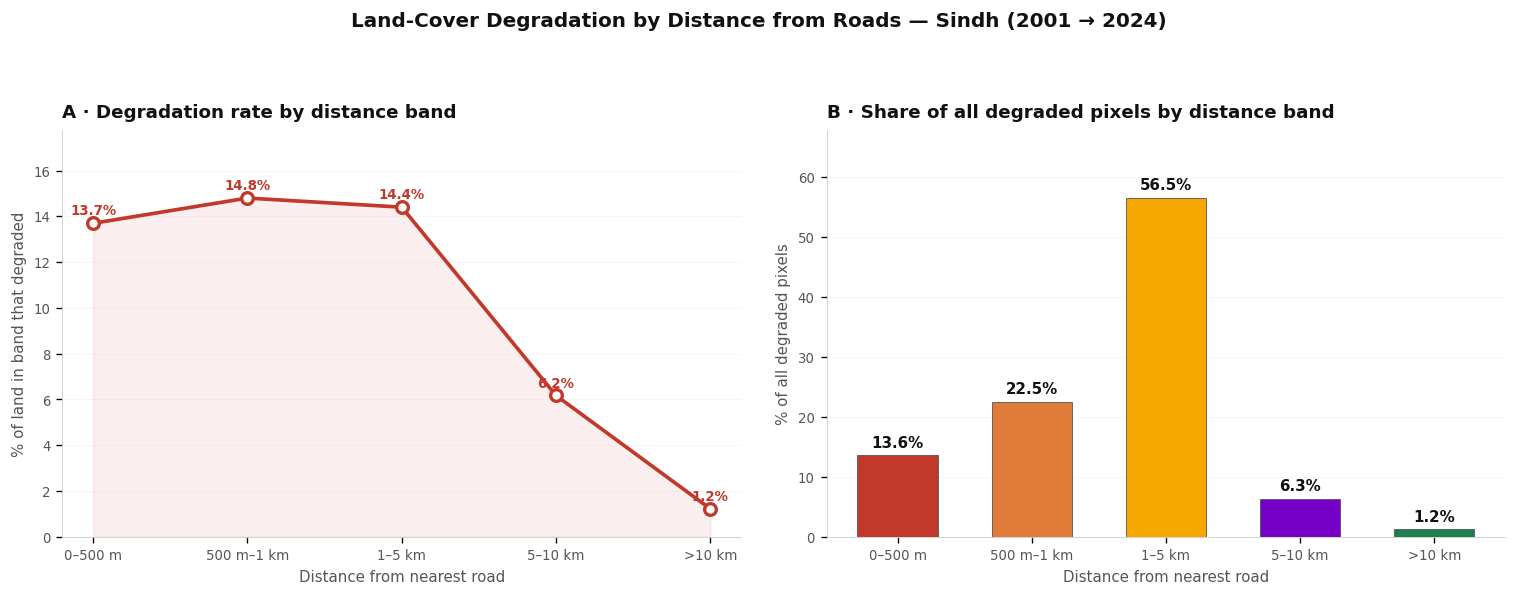

Saved → proximity_chart.png


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#FFFFFF")

ACCENT     = "#C1392B"
BAR_COLORS = ["#C1392B", "#E07B39", "#F4A800", "#7700C7", "#1B7F4F"]

# Panel A — degradation rate
ax1.set_facecolor("#FFFFFF")
ax1.plot(labels, rate_pct, marker="o", linewidth=2.2, color=ACCENT,
         markerfacecolor="#FFFFFF", markeredgecolor=ACCENT,
         markeredgewidth=2, markersize=7, zorder=4)
ax1.fill_between(labels, rate_pct, alpha=0.08, color=ACCENT)
for x, y in enumerate(rate_pct):
    ax1.text(x, y + max(rate_pct) * 0.025, f"{y:.1f}%",
             ha="center", fontsize=8, color=ACCENT, fontweight="bold")
ax1.set_title("A · Degradation rate by distance band",
              fontsize=11, fontweight="bold", color="#111", pad=8, loc="left")
ax1.set_xlabel("Distance from nearest road", fontsize=9, color="#555")
ax1.set_ylabel("% of land in band that degraded", fontsize=9, color="#555")
ax1.set_ylim(0, max(rate_pct) * 1.2)
ax1.tick_params(labelsize=8, labelcolor="#555")
ax1.grid(axis="y", linestyle="--", linewidth=0.3, color="#DDD", alpha=0.7)
for sp in ["top","right"]:   ax1.spines[sp].set_visible(False)
for sp in ["left","bottom"]: ax1.spines[sp].set(linewidth=0.5, color="#CCC")

# Panel B — share of all degradation
ax2.set_facecolor("#FFFFFF")
bars = ax2.bar(labels, share_pct, color=BAR_COLORS,
               edgecolor="#555", linewidth=0.5, width=0.6, zorder=3)
for bar, val in zip(bars, share_pct):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(share_pct) * 0.025,
             f"{val:.1f}%", ha="center", fontsize=9,
             fontweight="bold", color="#111")
ax2.set_title("B · Share of all degraded pixels by distance band",
              fontsize=11, fontweight="bold", color="#111", pad=8, loc="left")
ax2.set_xlabel("Distance from nearest road", fontsize=9, color="#555")
ax2.set_ylabel("% of all degraded pixels", fontsize=9, color="#555")
ax2.tick_params(labelsize=8, labelcolor="#555")
ax2.set_ylim(0, max(share_pct) * 1.2)
ax2.grid(axis="y", linestyle="--", linewidth=0.3, color="#DDD", alpha=0.7)
for sp in ["top","right"]:   ax2.spines[sp].set_visible(False)
for sp in ["left","bottom"]: ax2.spines[sp].set(linewidth=0.5, color="#CCC")

plt.suptitle(
    "Land-Cover Degradation by Distance from Roads — Sindh (2001 → 2024)",
    fontsize=12, fontweight="bold", color="#111", y=1.01,
)
plt.tight_layout(pad=2.0)
plt.savefig(OUTPUT_PATH + "proximity_chart.png",
            dpi=240, bbox_inches="tight", facecolor="#FFFFFF")
plt.show()
print("Saved → proximity_chart.png")


### 5.6 Roads & Degradation Hotspot Map

/tmp/ipykernel_83718/1452576782.py:65: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  area_q35 = districts.geometry.area.quantile(0.35)


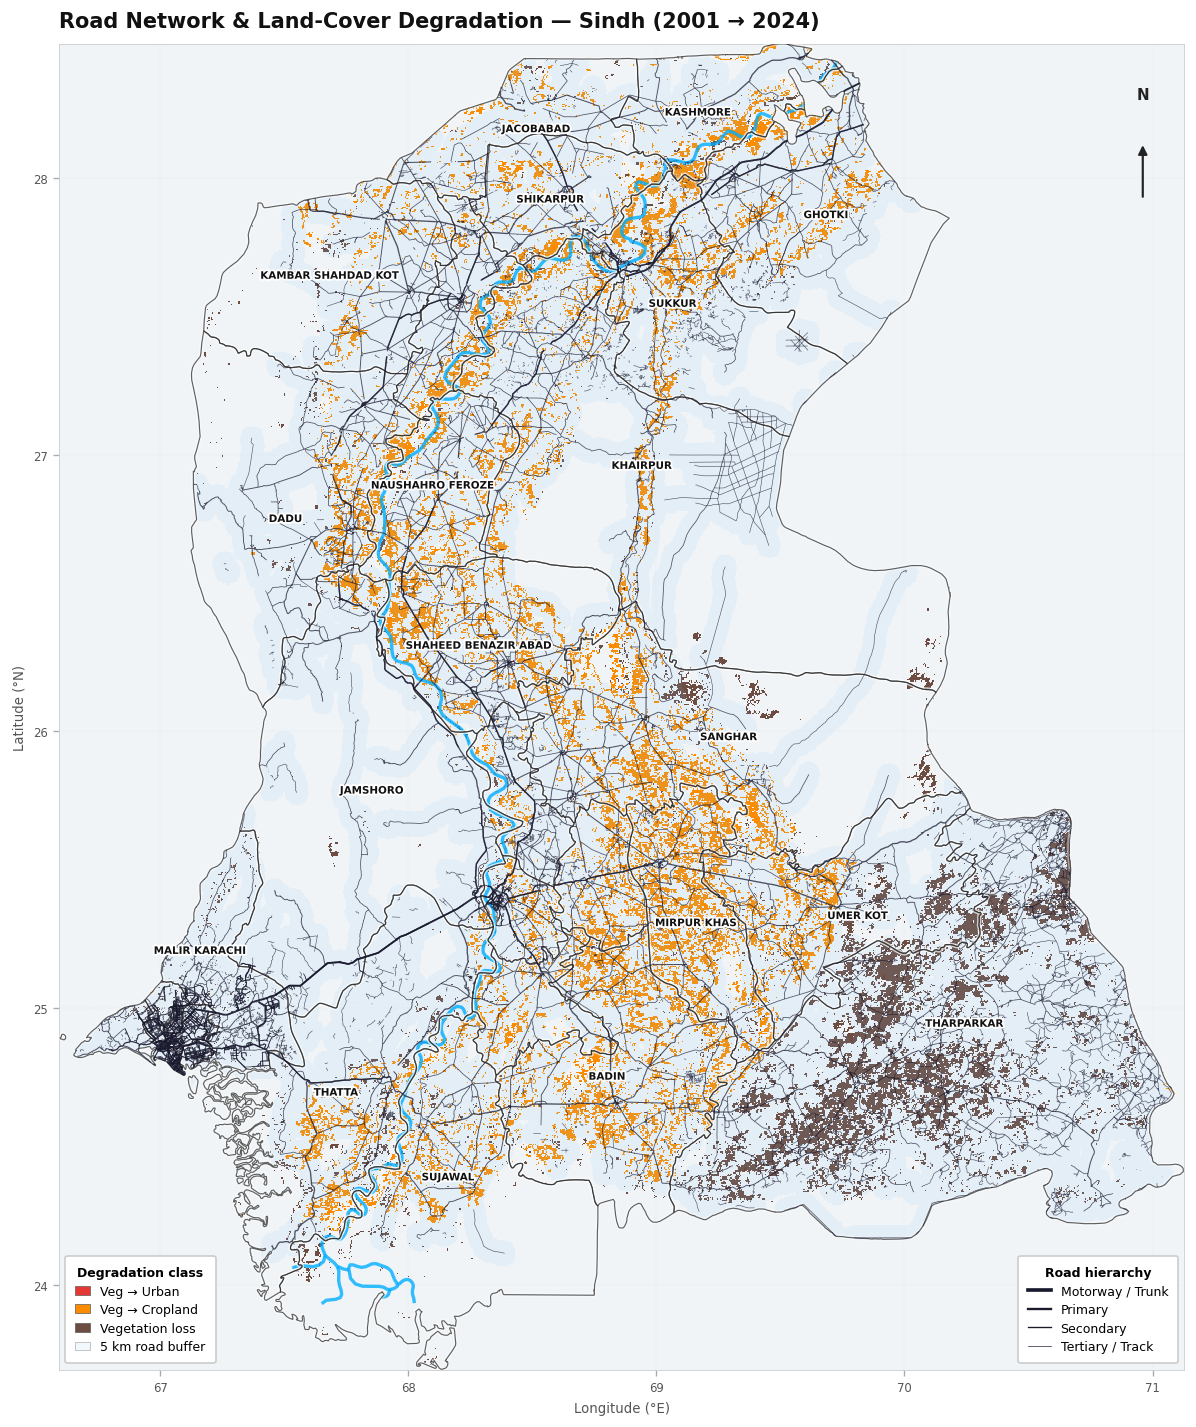

Saved → roads_degradation_map.png


In [17]:
# =========================================================
# MAP — Roads (single color, thickness by type) + Degradation
# =========================================================

DEG_COLORS = {   # degradation classes from Section 2.3
    1: "#e53935",  # Veg → Urban
    2: "#fb8c00",  # Veg → Cropland
    3: "#6d4c41",  # Vegetation loss
}

rgba = np.zeros((*shape, 4), dtype=np.float32)

for cls_id, hex_color in DEG_COLORS.items():
    mask = (cls == cls_id)
    rgba[mask] = to_rgba(hex_color)

fig, ax = plt.subplots(figsize=(13, 12))
fig.patch.set_facecolor("#FFFFFF")
ax.set_facecolor("#F0F4F7")

# degradation raster
ax.imshow(rgba, extent=extent, interpolation="nearest",
          origin="upper", zorder=2)

# 5 km road buffer — very faint
buffer_rgba = np.zeros((*shape, 4), dtype=np.float32)
buffer_rgba[(dist_m <= 5_000) & valid] = to_rgba("#81C5FC1C")
ax.imshow(buffer_rgba, extent=extent, interpolation="nearest",
          origin="upper", zorder=3)

rivers.plot(
    ax=ax,
    color="#00AEFF",
    linewidth=2,
    alpha=0.8,
    zorder=4
)

# district boundaries
districts.boundary.plot(ax=ax, linewidth=2.5, color="#FFFFFF", alpha=0.45, zorder=4)
districts.boundary.plot(ax=ax, linewidth=0.7,  color="#2C2C2C", alpha=0.75, zorder=5)

# ── Roads — single dark color, linewidth by hierarchy ──────
ROAD_COLOR = "#1A1A2E"   # near-black navy — readable over all degradation hues

road_lw = {
    "motorway":     1,
    "trunk":        0.8,
    "primary":      0.625,
    "secondary":    0.55,
    "tertiary":     0.45,
    "track":        0.35,
}

for rtype, grp in roads.groupby("highway"):
    grp.plot(
        ax        = ax,
        color     = ROAD_COLOR,
        linewidth = road_lw.get(rtype, 0.2),
        alpha     = 0.75,
        zorder    = 6,
    )

# district labels
area_q35 = districts.geometry.area.quantile(0.35)
halo     = pe.withStroke(linewidth=2.2, foreground="#FFFFFF")
for _, row in districts.iterrows():
    if row.geometry.area < area_q35:
        continue
    pt = row.geometry.representative_point()
    ax.text(pt.x, pt.y, row["district"].upper(),
            fontsize=6.2, fontweight="bold", color="#111111",
            ha="center", va="center", path_effects=[halo], zorder=7)

# axes
for sp in ax.spines.values():
    sp.set_linewidth(0.5); sp.set_edgecolor("#CCCCCC")
ax.tick_params(labelsize=7, color="#AAAAAA", labelcolor="#555555")
ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
ax.set_xlabel("Longitude (°E)", fontsize=8, color="#555")
ax.set_ylabel("Latitude (°N)",  fontsize=8, color="#555")
ax.grid(True, linestyle="--", linewidth=0.25, color="#CCCCCC", alpha=0.35, zorder=1)

ax.set_title(
    "Road Network & Land-Cover Degradation — Sindh (2001 → 2024)",
    fontsize=12.5, fontweight="bold", color="#111", pad=10, loc="left",
)

deg_patches = [
    Patch(facecolor=DEG_COLORS[1], label="Veg → Urban",      edgecolor="#555", lw=0.4),
    Patch(facecolor=DEG_COLORS[2], label="Veg → Cropland",   edgecolor="#555", lw=0.4),
    Patch(facecolor=DEG_COLORS[3], label="Vegetation loss",  edgecolor="#555", lw=0.4),
    Patch(facecolor="#81C5FC1C", label="5 km road buffer", edgecolor="#AAAAAA", lw=0.4),
]

road_lines = [
    Line2D([0],[0], color=ROAD_COLOR, linewidth=2.2, label="Motorway / Trunk"),
    Line2D([0],[0], color=ROAD_COLOR, linewidth=1.4, label="Primary"),
    Line2D([0],[0], color=ROAD_COLOR, linewidth=0.8, label="Secondary"),
    Line2D([0],[0], color=ROAD_COLOR, linewidth=0.4, label="Tertiary / Track"),
]

leg1 = ax.legend(handles=deg_patches, title="Degradation class",
                 title_fontsize=7.5, fontsize=7.5, loc="lower left",
                 frameon=True, framealpha=1.0, facecolor="#FFFFFF",
                 edgecolor="#CCCCCC", borderpad=0.8, labelspacing=0.45,
                 handlelength=1.2)
leg1.get_title().set_fontweight("bold")

leg2 = ax.legend(handles=road_lines, title="Road hierarchy",
                 title_fontsize=7.5, fontsize=7.5, loc="lower right",
                 frameon=True, framealpha=1.0, facecolor="#FFFFFF",
                 edgecolor="#CCCCCC", borderpad=0.8, labelspacing=0.45,
                 handlelength=1.8)
leg2.get_title().set_fontweight("bold")

ax.add_artist(leg1)

# north arrow
ax.annotate("N", xy=(0.963, 0.962), xycoords="axes fraction",
            ha="center", va="center", fontsize=9,
            fontweight="bold", color="#222", annotation_clip=False)
ax.annotate("", xy=(0.963, 0.926), xytext=(0.963, 0.882),
            xycoords="axes fraction", textcoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", color="#222",
                            lw=1.3, mutation_scale=11),
            annotation_clip=False)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "roads_degradation_map.png",
            dpi=240, bbox_inches="tight", facecolor="#FFFFFF")
plt.show()
print("Saved → roads_degradation_map.png")